In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.figure(figsize=(8, 8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

## 答题卡识别

In [13]:
def four_point_transform(image, pts):
	# 获取输入坐标点（得到的四个点）
	rect = order_points(pts)
	(tl, tr, br, bl) = rect

	# 计算输入的w和h值
	widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
	widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
	maxWidth = max(int(widthA), int(widthB))

	heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
	heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
	maxHeight = max(int(heightA), int(heightB))

	# 变换后对应坐标位置（用数组存储对应的四个坐标点）
	dst = np.array([
		[0, 0],
		[maxWidth - 1, 0],
		[maxWidth - 1, maxHeight - 1],
		[0, maxHeight - 1]], dtype = "float32")

	# 计算变换矩阵
	M = cv2.getPerspectiveTransform(rect, dst)
	warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

	# 返回变换后结果
	return warped

def sort_contours(cnts, method="left-to-right"):
    reverse = False
    i = 0
    if method == "right-to-left" or method == "bottom-to-top":
        reverse = True
    if method == "top-to-bottom" or method == "bottom-to-top":
        i = 1
    boundingBoxes = [cv2.boundingRect(c) for c in cnts]
    (cnts, boundingBoxes) = zip(*sorted(zip(cnts, boundingBoxes),
                                        key=lambda b: b[1][i], reverse=reverse))
    return cnts, boundingBoxes


def order_points(pts):
	# 一共4个坐标点
	rect = np.zeros((4, 2), dtype = "float32")

	# 按顺序找到对应坐标0123分别是 左上，右上，右下，左下
	# 计算左上，右下
	s = pts.sum(axis = 1)
	rect[0] = pts[np.argmin(s)]
	rect[2] = pts[np.argmax(s)]

	# 计算右上和左下
	diff = np.diff(pts, axis = 1)
	rect[1] = pts[np.argmin(diff)]
	rect[3] = pts[np.argmax(diff)]

	return rect

def cv_show(title, img, index, gray = False):
	if gray:
		plt.subplot(index), plt.imshow(img, 'gray'), plt.title(title), plt.axis('off')
	else:
		plt.subplot(index), plt.imshow(img), plt.title(title), plt.axis('off')
	if index == 233:
		plt.show()
		plt.figure(figsize=(12, 12))


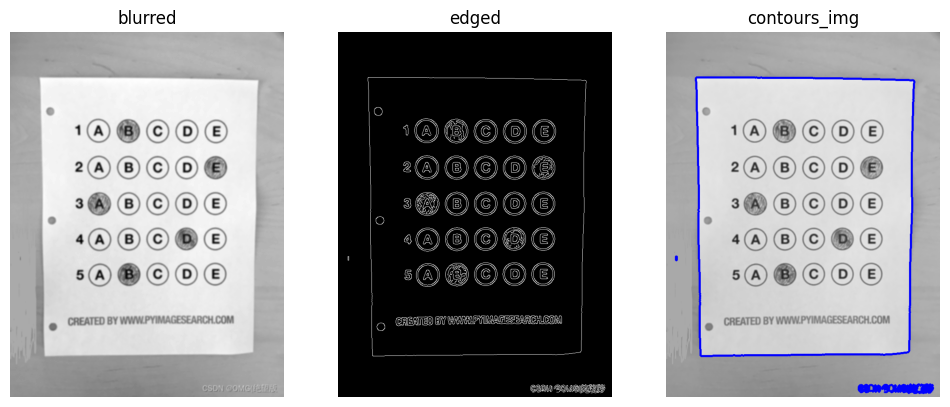

len(cnts) ===  21


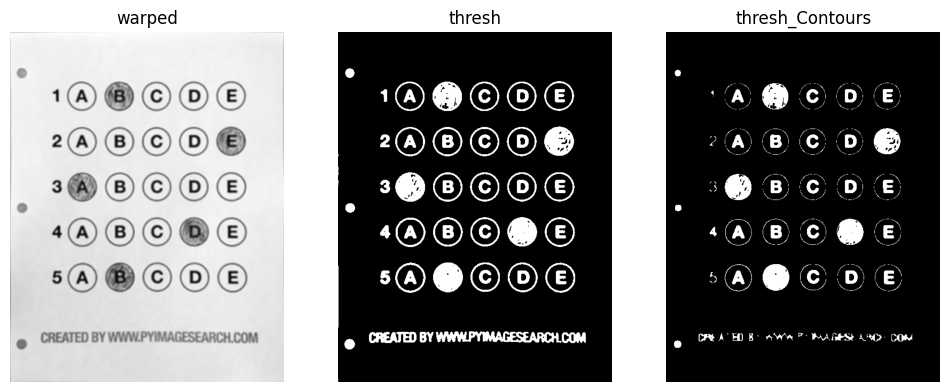

[INFO] score: 100.00%


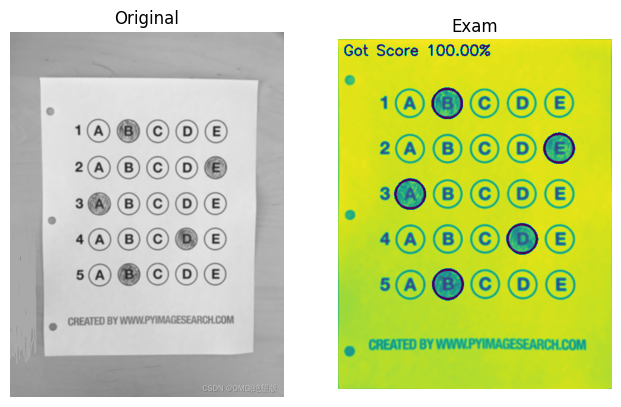

In [22]:
# 正确答案
ANSWER_KEY = {0: 1, 1: 4, 2: 0, 3: 3, 4: 1}

plt.figure(figsize=(12, 12))
# 预处理
image = cv2.imread('./assets/card.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
cv_show('blurred',blurred, 231, True)
edged = cv2.Canny(blurred, 20, 100)
cv_show('edged',edged, 232, True)

# 轮廓检测
cnts = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL,
	cv2.CHAIN_APPROX_SIMPLE)[0]
contours_img = image.copy()
cv2.drawContours(contours_img,cnts,-1,(0,0,255),3) 
cv_show('contours_img',contours_img, 233)

docCnt = None

# 确保检测到了
print('len(cnts) === ', len(cnts))
if len(cnts) > 0:
	# 根据轮廓大小进行排序
	cnts = sorted(cnts, key=cv2.contourArea, reverse=True)

	# 遍历每一个轮廓
	for c in cnts:
		# 近似
		peri = cv2.arcLength(c, True)
		approx = cv2.approxPolyDP(c, 0.02 * peri, True)

		# 准备做透视变换
		if len(approx) == 4:
			docCnt = approx
			break

# 执行透视变换
warped = four_point_transform(gray, docCnt.reshape(4, 2))
cv_show('warped',warped, 231, True)
# Otsu's 阈值处理
thresh = cv2.threshold(warped, 0, 255,
	cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1] 
cv_show('thresh',thresh, 232, True)
thresh_Contours = thresh.copy()

# 找到每一个圆圈轮廓
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
	cv2.CHAIN_APPROX_SIMPLE)[0]
cv2.drawContours(thresh_Contours,cnts,-1,(0,0,255),3) 
cv_show('thresh_Contours',thresh_Contours, 233, True)
questionCnts = []

# 遍历
for c in cnts:
	# 通过做外接矩形，计算外接矩形长宽的大小和比例，如果比例为1或接近于1则代表是个圆形
	(x, y, w, h) = cv2.boundingRect(c)
	ar = w / float(h)

	# 根据实际情况指定标准（有误差）
	if w >= 20 and h >= 20 and ar >= 0.9 and ar <= 1.1:
		questionCnts.append(c)

# 按照从上到下进行排序（圆圈）
questionCnts = sort_contours(questionCnts,
	method="top-to-bottom")[0]
correct = 0
# 同一道题的选项，x轴值相同y轴值不同
# 每排有5个选项（△）
for (q, i) in enumerate(np.arange(0, len(questionCnts), 5)):
	# 排序
	cnts = sort_contours(questionCnts[i:i + 5])[0]
	bubbled = None

	# 遍历每一个结果
	for (j, c) in enumerate(cnts):
		# 使用mask（掩码）（与操作）来判断结果
		mask = np.zeros(thresh.shape, dtype="uint8")
		cv2.drawContours(mask, [c], -1, 255, -1) #-1表示填充
		# cv_show('mask',mask)
		# 通过计算非零点数量来算是否选择这个答案
		# 此处的mask是该选项的实际值（计算像素点的差异？）
		# 执行与操作（255+255/255+0?）
		mask = cv2.bitwise_and(thresh, thresh, mask=mask)

		total = cv2.countNonZero(mask)

		# 通过阈值判断，找到当前题目不为0的所选答案
		if bubbled is None or total > bubbled[0]:
			bubbled = (total, j)

	# 对比正确答案
	color = (0, 0, 255)
	if q >= len(ANSWER_KEY):
		break
	k = ANSWER_KEY[q]

	# 判断正确
	if k == bubbled[1]:
		# 绿色
		color = (0, 255, 0)
		correct += 1

	# 绘图
	cv2.drawContours(warped, [cnts[k]], -1, color, 3)


score = (correct / 5.0) * 100
print("[INFO] score: {:.2f}%".format(score))
cv2.putText(warped, "Got Score {:.2f}%".format(score), (10, 30),
	cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
cv_show("Original", image, 231)
cv_show("Exam", warped, 232)